=== HDU INFO ===
Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

=== BASIC INFO ===
Number of HDUs: 2
Image HDU index: 0 (PRIMARY)
Data dtype: >i2
BITPIX: 16

hdr keys
SIMPLE = True
BITPIX = 16
NAXIS = 2
NAXIS1 = 530
NAXIS2 = 530

=== SHAPE INFO ===
Data shape: (530, 530)
NAXIS1: 530 NAXIS2: 530
Matches shape?: True

=== STATISTICS ===
Min: 1507
Max: 15752
Mean: 4795.924268422927
Std: 1848.2526085366376
Median: 4102.0
Mode: 3551

=== FLOAT DATA INFO ===
Converted dtype: float64



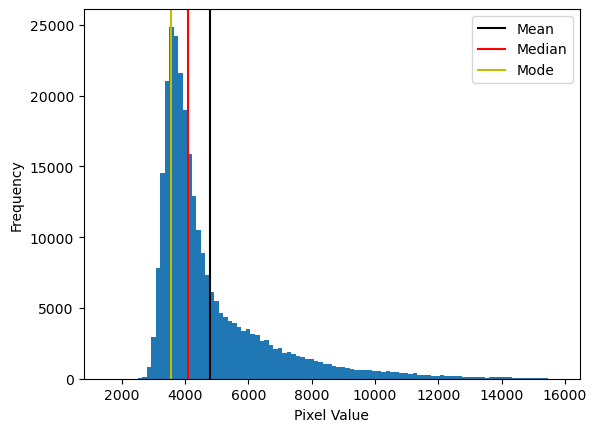

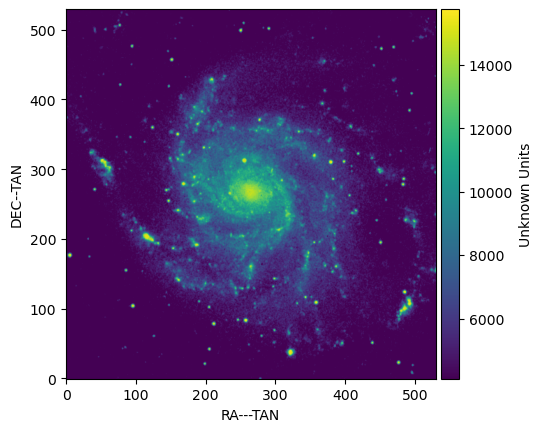

In [13]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Open FITS file
hdul = fits.open('m101.fits', memmap=False)

# Info about HDUs
print("=== HDU INFO ===")
hdul.info()
print()

# Access primary HDU
hdu = hdul[0]
hdr = hdu.header
dat = hdu.data

# Basic info
print("=== BASIC INFO ===")
print("Number of HDUs:", len(hdul))
print("Image HDU index: 0 (PRIMARY)")
print("Data dtype:", dat.dtype)
print("BITPIX:", hdr['BITPIX'])
print()
#Header keys
print("hdr keys")
keys = list(hdr.keys())[:5]
for k in keys:
    print(k, "=", hdr[k])
print()


print("Data shape:", dat.shape)
print()
# Statistics
flat = dat.flatten()

minimum = np.min(flat)
maximum = np.max(flat)
mean = np.mean(flat)
std = np.std(flat)
median = np.median(flat)
mode = stats.mode(flat, keepdims=True)[0][0]

print("=== STATISTICS ===")
print("Min:", minimum)
print("Max:", maximum)
print("Mean:", mean)
print("Std:", std)
print("Median:", median)
print("Mode:", mode)
print()

fig1, ax1 = plt.subplots()
ax1.hist(flat, bins=67)

ax1.axvline(mean, label='Mean',color="k")
ax1.axvline(median, label='Median',color="r")
ax1.axvline(mode, label='Mode',color="y")

ax1.set_xlabel('Pixel Value')
ax1.set_ylabel('Frequency')
ax1.legend()

# Convert to float
dat_float = np.asarray(dat, dtype=float)
median_val = np.median(dat_float)

print("=== FLOAT DATA INFO ===")
print("Converted dtype:", dat_float.dtype)
print()

# Image plot (OO)
fig2, ax2 = plt.subplots()
im = ax2.imshow(dat_float, vmin=median_val, origin='lower')

ax2.set_xlabel(hdr.get('CTYPE1', 'X'))
ax2.set_ylabel(hdr.get('CTYPE2', 'Y'))

# Colorbar (locatable)
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.05)

cbar = fig2.colorbar(im, cax=cax)
cbar.set_label(hdr.get('BUNIT', 'Unknown Units'))

# Add BUNIT and save
hdr['BUNIT'] = 'Counts'
new_hdu = fits.PrimaryHDU(data=dat_float, header=hdr)
new_hdu.writeto('m101_float.fits', overwrite=True, output_verify='silentfix')

plt.show()
hdul.close()

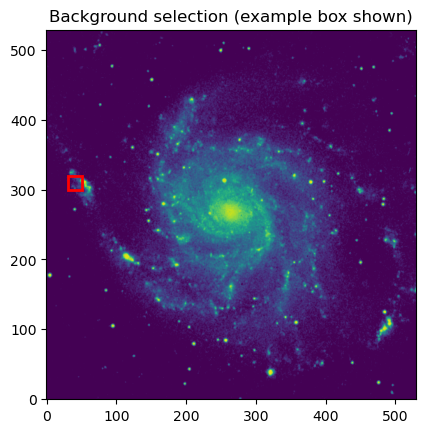

=== BACKGROUND REGION STATS ===
Slice used: y=300:320, x=30:50
Mean: 5339.2475
Standard deviation: 1406.4389681901416
RMS: 5521.379758493343

Difference (RMS - STD): 4114.940790303201


In [39]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open FITS file
hdul = fits.open('m101.fits', memmap=False)
dat = hdul[0].data

# ---- SHOW IMAGE TO CHOOSE REGION ----
fig, ax = plt.subplots()
im = ax.imshow(dat, origin='lower', vmin=np.median(dat))
ax.set_title("Background selection (example box shown)")

# ---- DEFINE 20x20 BACKGROUND REGION (EDIT THESE INDICES IF NEEDED) ----
y1, y2 = 300,320
x1, x2 = 30, 50

sub = dat[y1:y2, x1:x2]

# Draw rectangle on image
rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', facecolor='none', linewidth=2)
ax.add_patch(rect)

plt.show()

# ---- STATISTICS ----
flat = sub.flatten()
flat = flat.astype(float) #Data might overflow if it excedes limit when squaring
mean = np.mean(flat)
std = np.std(flat)
rms = np.sqrt(np.mean(flat**2))

print("=== BACKGROUND REGION STATS ===")
print(f"Slice used: y={y1}:{y2}, x={x1}:{x2}")
print("Mean:", mean)
print("Standard deviation:", std)
print("RMS:", rms)

# ---- EXTRA CHECK ----
print("\nDifference (RMS - STD):", rms - std)
# Close file
hdul.close()

In [41]:
from astropy.io import fits
import numpy as np

# ---- LOAD DATA ----
files = ['noisemap0.fits', 'noisemap1.fits', 'noisemap2.fits']
data_list = []

for f in files:
    hdul = fits.open(f, memmap=False)
    data = hdul[0].data.astype(float)
    data_list.append(data)
    hdul.close()

# ---- STANDARD DEVIATION OF EACH IMAGE ----
print("=== INDIVIDUAL IMAGE STDS ===")
stds = []
for i, dat in enumerate(data_list):
    std = np.std(dat)
    stds.append(std)
    print(f"Image {i} std:", std)

# ---- STACK IN Z DIRECTION ----
stack = np.stack(data_list, axis=0)  # shape: (3, ny, nx)

print("\nStack shape:", stack.shape)

# ---- MEAN IMAGE ----
mean_image = np.mean(stack, axis=0)

# ---- STANDARD DEVIATION OF MEAN IMAGE ----
std_mean_image = np.std(mean_image)

print("\n=== MEAN IMAGE ===")
print("Std of mean image:", std_mean_image)

# ---- THEORETICAL EXPECTATION ----
# Noise reduction: sigma_mean = sigma / sqrt(N)
N = len(data_list)
mean_std = np.mean(stds)
expected_std = mean_std / np.sqrt(N)

print("\n=== COMPARISON ===")
print("Average individual std:", mean_std)
print("Expected std after stacking:", expected_std)
print("Measured std after stacking:", std_mean_image)
print("Ratio (measured / expected):", std_mean_image / expected_std)

=== INDIVIDUAL IMAGE STDS ===
Image 0 std: 9.984015566794838
Image 1 std: 10.003955116338462
Image 2 std: 9.995349488722518

Stack shape: (3, 893, 891)

=== MEAN IMAGE ===
Std of mean image: 5.773191380233297

=== COMPARISON ===
Average individual std: 9.994440057285273
Expected std after stacking: 5.770292657473231
Measured std after stacking: 5.773191380233297
Ratio (measured / expected): 1.0005023528150365


In [44]:
from astropy.io import fits
import numpy as np

# ---- LOAD TABLE ----
hdul = fits.open('APOGEE_stars.fits', memmap=False)
data = hdul[1].data
cols = hdul[1].columns.names

print("Columns:")
print(cols)

# ---- QUALITY FLAGS ----
DATAFLAG = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
).astype(int)

# ---- ADD COLUMN TO TABLE ----
from astropy.table import Table

table = Table(data)
table['DATAFLAG'] = DATAFLAG

# ---- ABSOLUTE MAGNITUDE ----
# Distance modulus: M = m + 5 - 5 log10(d)
# parallax in mas → distance in pc = 1000 / parallax

parallax = data['GAIAEDR3_PARALLAX']
parallax_err = data['GAIAEDR3_PARALLAX_ERROR']

distance = np.where(parallax > 0, 1000.0 / parallax, np.nan)

abs_mag = np.full(len(table), -1.0)

valid = DATAFLAG == 1
abs_mag[valid] = (
    data['GAIAEDR3_PHOT_G_MEAN_MAG'][valid]
    + 5
    - 5 * np.log10(distance[valid])
)

table['ABS_MAG'] = abs_mag

# ---- SAVE UPDATED TABLE ----
table.write('APOGEE_update.fits', overwrite=True)

# ---- SHOW RESULT ----
print("\nUpdated columns:")
print(table.colnames)

print("\nFirst 5 rows:")
print(table[:5])

hdul.close()

Columns:
['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']

Updated columns:
['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR', 'DATAFLAG', 'ABS_MAG']

First 5 rows:
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG      ABS_MAG      
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1 2.7881622314453125


Columns:
Index(['source_id', 'ra', 'ra_error', 'dec', 'dec_error', 'phot_g_mean_flux',
       'phot_g_mean_flux_error', 'phot_g_mean_mag', 'phot_bp_mean_flux',
       'phot_bp_mean_flux_error', 'phot_bp_mean_mag', 'phot_rp_mean_flux',
       'phot_rp_mean_flux_error', 'phot_rp_mean_mag', 'a_g_val',
       'e_bp_min_rp_val'],
      dtype='str')

=== MAX FLUX ROW ===
source_id                  1.741834e+07
ra                         2.358429e+02
ra_error                   5.007553e-03
dec                        1.171101e+01
dec_error                  4.450002e-03
phot_g_mean_flux           4.248940e+07
phot_g_mean_flux_error     5.649703e+03
phot_g_mean_mag            6.617699e+00
phot_bp_mean_flux          1.572251e+07
phot_bp_mean_flux_error    9.947167e+03
phot_bp_mean_mag           7.360095e+00
phot_rp_mean_flux          3.165592e+07
phot_rp_mean_flux_error    2.005618e+04
phot_rp_mean_mag           6.010764e+00
a_g_val                    0.000000e+00
e_bp_min_rp_val            0.000

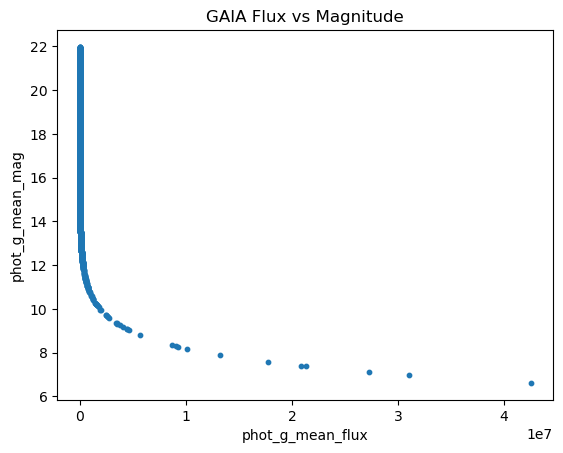


=== m0 ESTIMATE ===
Mean m0: 25.68840037029544

=== LINEAR FIT METHOD ===
Slope (should be ~ -2.5): -2.499999974137693
Intercept m0: 25.688400300372496


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD CSV INTO DATAFRAME
# -----------------------------
df = pd.read_csv("gaiaTestData.csv")

print("Columns:")
print(df.columns)

# -----------------------------
# 2. MAX FLUX ROW (phot_g_mean_flux)
# -----------------------------
max_flux_idx = df["phot_g_mean_flux"].idxmax()
max_row = df.loc[max_flux_idx]

print("\n=== MAX FLUX ROW ===")
print(max_row)

# -----------------------------
# 3. SORT BY FLUX
# -----------------------------
df_sorted = df.sort_values(by="phot_g_mean_flux")

# -----------------------------
# 4. SCATTER PLOT (OO STYLE)
# -----------------------------
fig, ax = plt.subplots()

logF = np.log10(df["phot_g_mean_flux"])
m = df["phot_g_mean_mag"]

a, b = np.polyfit(logF, m, 1)
ax.scatter(x, y, s=10)

ax.set_xlabel("phot_g_mean_flux")
ax.set_ylabel("phot_g_mean_mag")
ax.set_title("GAIA Flux vs Magnitude")

plt.show()

# -----------------------------
# 5. COMPUTE m0 VALUES
# -----------------------------
# m0 = m + 2.5 log10(F)

F = df["phot_g_mean_flux"]
m = df["phot_g_mean_mag"]

m0_values = m + 2.5 * np.log10(F)

# remove invalid values (log issues)
m0_values = m0_values.replace([np.inf, -np.inf], np.nan).dropna()

m0_mean = np.mean(m0_values)

print("\n=== m0 ESTIMATE ===")
print("Mean m0:", m0_mean)

# -----------------------------
# 6. ALTERNATIVE: LINEAR FIT (MORE CORRECT)
# m = m0 - 2.5 log10(F)
# -----------------------------
logF = np.log10(F)

# remove invalid entries
mask = np.isfinite(logF) & np.isfinite(m)

logF_clean = logF[mask]
m_clean = m[mask]

# linear fit: m = a * logF + b
a, b = np.polyfit(logF_clean, m_clean, 1)

print("\n=== LINEAR FIT METHOD ===")
print("Slope (should be ~ -2.5):", a)
print("Intercept m0:", b)

In [53]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

# -----------------------------
# 1. ADQL QUERY (GAIA DR3)
# -----------------------------
query = """
SELECT TOP 50
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE
    parallax / parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY RANDOM_INDEX
"""

# -----------------------------
# 2. RUN QUERY
# -----------------------------
job = Gaia.launch_job(query)
results = job.get_results()

# -----------------------------
# 3. PANDAS DATAFRAME
# -----------------------------
df = results.to_pandas()

print("DataFrame preview:")
print(df.head())

# -----------------------------
# 4. CONVERT TO FITS AND SAVE
# -----------------------------
table = Table.from_pandas(df)
table.write("astroquery_gaia.fits", overwrite=True)

print("\nSaved file: astroquery_gaia.fits")

<class 'KeyError'>: 'astropy'

In [58]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def nth_term(self, N):
        """Return the N-th Fibonacci number"""
        a, b = 0, 1
        for _ in range(N + 1):
            a, b = b, a + b
        return a

    def divisible_by_m(self, N, M):
            # Get the N-th Fibonacci value as the upper limit
        limit = self.nth_term(N)

        fibnum = []
        a, b = 0, 1

        for _ in range(N + 1):
            if a % M == 0:
                fibnum.append(a)

            a, b = b, a + b

            # stop early if we exceed the N-th term value
            if a >= limit:
                break

        return fibnum


# ---------------- TEST ----------------
fib = Fibonacci()

N = 100
M = 7

print("N-th Fibonacci term:", fib.nth_term(N))
print("Fibonacci numbers <= N-th term divisible by M:", fib.divisible_by_m(N, M))

N-th Fibonacci term: 573147844013817084101
Fibonacci numbers <= N-th term divisible by M: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
